In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris/Iris.csv
/kaggle/input/iris/database.sqlite


In [14]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Iris.csv')

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df = df.iloc[:,1:] # remove Id column

In [5]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
encoder = LabelEncoder()

In [9]:
df['Species'] = encoder.fit_transform(df['Species'])

In [10]:
df.head()

,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [11]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [12]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


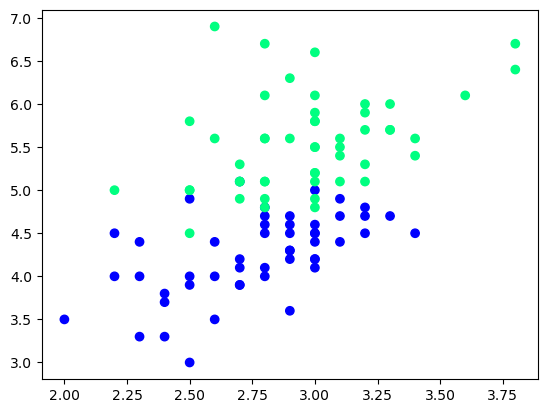

In [15]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [16]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
108,2.5,5.8,2
71,2.8,4.0,1
92,2.6,4.0,1
59,2.7,3.9,1
90,2.6,4.4,1
94,2.7,4.2,1
65,3.1,4.4,1
103,2.9,5.6,2
70,3.2,4.8,1
98,2.5,3.0,1


In [17]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [18]:
df_train

,SepalWidthCm,PetalLengthCm,Species
141,3.1,5.1,2
62,2.2,4.0,1
130,2.8,6.1,2
124,3.3,5.7,2
143,3.2,5.9,2
77,3.0,5.0,1
56,3.3,4.7,1
111,2.7,5.3,2
120,3.2,5.7,2
85,3.4,4.5,1


In [19]:
df_val

,SepalWidthCm,PetalLengthCm,Species
102,3.0,5.9,2
108,2.5,5.8,2
118,2.6,6.9,2
114,2.8,5.1,2
58,2.9,4.6,1


In [20]:
df_test

,SepalWidthCm,PetalLengthCm,Species
137,3.1,5.5,2
145,3.0,5.2,2
117,3.8,6.7,2
136,3.4,5.6,2
68,2.2,4.5,1


In [21]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [22]:
y_test

array([2, 2, 2, 2, 1])

# Case 1 - Bagging

In [44]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True) # replace = True means that there can be repeated values

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
141,3.1,5.1,2
130,2.8,6.1,2
141,3.1,5.1,2
111,2.7,5.3,2
77,3.0,5.0,1
62,2.2,4.0,1
124,3.3,5.7,2
120,3.2,5.7,2


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [27]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

In [28]:
dt_bag1 = DecisionTreeClassifier()

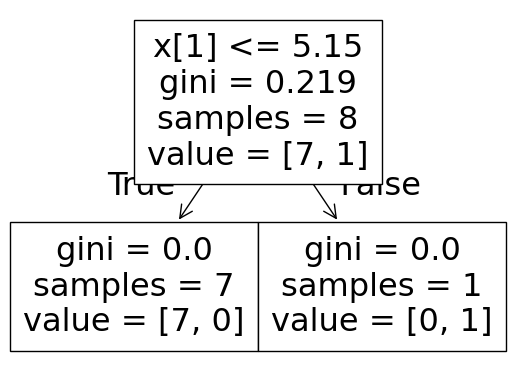

c:\Users\Sanjog Bhalla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Sanjog Bhalla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


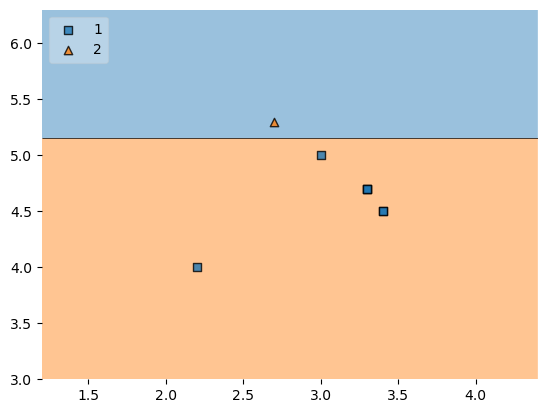

In [29]:
evaluate(dt_bag1,X,y)

In [30]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
120,3.2,5.7,2
143,3.2,5.9,2
124,3.3,5.7,2
143,3.2,5.9,2
56,3.3,4.7,1
143,3.2,5.9,2
130,2.8,6.1,2
77,3.0,5.0,1


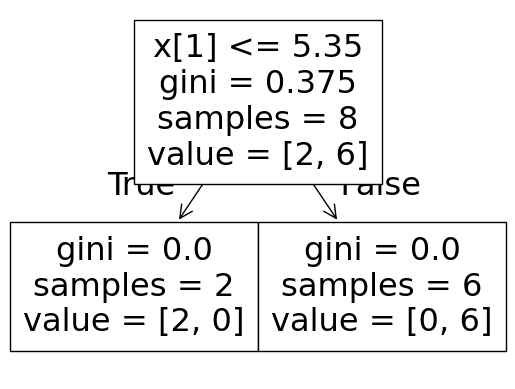

c:\Users\Sanjog Bhalla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Sanjog Bhalla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


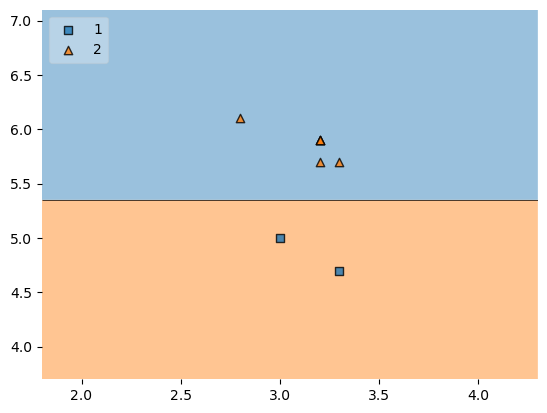

In [31]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [32]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
77,3.0,5.0,1
62,2.2,4.0,1
143,3.2,5.9,2
111,2.7,5.3,2
120,3.2,5.7,2
111,2.7,5.3,2
141,3.1,5.1,2
56,3.3,4.7,1


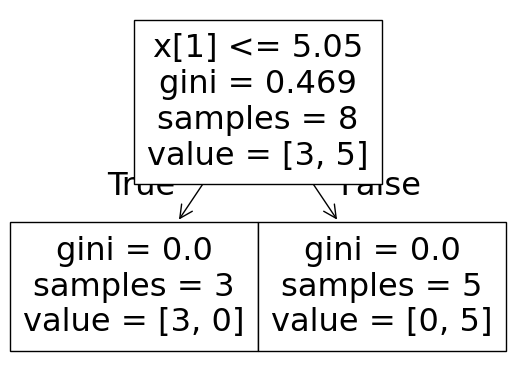

c:\Users\Sanjog Bhalla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Sanjog Bhalla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


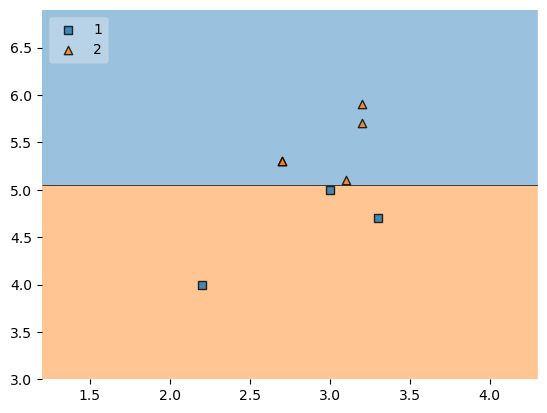

In [33]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [34]:
df_test

,SepalWidthCm,PetalLengthCm,Species
137,3.1,5.5,2
145,3.0,5.2,2
117,3.8,6.7,2
136,3.4,5.6,2
68,2.2,4.5,1


In [36]:
print("Predictor 1",dt_bag1.predict(np.array([3.0,5.2]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([3.0,5.2]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([3.0,5.2]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [1]
Predictor 3 [2]


c:\Users\Sanjog Bhalla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Sanjog Bhalla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Sanjog Bhalla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [37]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
141,3.1,5.1,2
62,2.2,4.0,1
130,2.8,6.1,2
124,3.3,5.7,2
143,3.2,5.9,2
77,3.0,5.0,1
56,3.3,4.7,1
111,2.7,5.3,2
120,3.2,5.7,2
85,3.4,4.5,1


In [38]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
141,3.1,5.1,2
56,3.3,4.7,1
77,3.0,5.0,1
111,2.7,5.3,2
130,2.8,6.1,2
143,3.2,5.9,2
124,3.3,5.7,2
120,3.2,5.7,2


# Random Subspaces

In [39]:
df1 = pd.read_csv('Iris.csv')
df1 = df1.sample(10)

In [40]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
58,59,6.6,2.9,4.6,1.3,Iris-versicolor
66,67,5.6,3.0,4.5,1.5,Iris-versicolor
126,127,6.2,2.8,4.8,1.8,Iris-virginica
107,108,7.3,2.9,6.3,1.8,Iris-virginica
105,106,7.6,3.0,6.6,2.1,Iris-virginica
68,69,6.2,2.2,4.5,1.5,Iris-versicolor
130,131,7.4,2.8,6.1,1.9,Iris-virginica
133,134,6.3,2.8,5.1,1.5,Iris-virginica
88,89,5.6,3.0,4.1,1.3,Iris-versicolor
77,78,6.7,3.0,5.0,1.7,Iris-versicolor


In [41]:
df1.sample(2,replace=True,axis=1)

,SepalLengthCm,SepalWidthCm
58,6.6,2.9
66,5.6,3.0
126,6.2,2.8
107,7.3,2.9
105,7.6,3.0
68,6.2,2.2
130,7.4,2.8
133,6.3,2.8
88,5.6,3.0
77,6.7,3.0


# Random Patches

In [42]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
58,59,6.6,2.9,4.6,1.3,Iris-versicolor
66,67,5.6,3.0,4.5,1.5,Iris-versicolor
126,127,6.2,2.8,4.8,1.8,Iris-virginica
107,108,7.3,2.9,6.3,1.8,Iris-virginica
105,106,7.6,3.0,6.6,2.1,Iris-virginica
68,69,6.2,2.2,4.5,1.5,Iris-versicolor
130,131,7.4,2.8,6.1,1.9,Iris-virginica
133,134,6.3,2.8,5.1,1.5,Iris-virginica
88,89,5.6,3.0,4.1,1.3,Iris-versicolor
77,78,6.7,3.0,5.0,1.7,Iris-versicolor


In [43]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,PetalLengthCm,SepalWidthCm
68,4.5,2.2
130,6.1,2.8
105,6.6,3.0
105,6.6,3.0
88,4.1,3.0
105,6.6,3.0
88,4.1,3.0
130,6.1,2.8
